# CIFAR-10 CNN with Saliency Maps That Explain a Trained Model

## Goal

Train a convolutional neural network on CIFAR-10, measure held-out performance,
inspect its confusion matrix, and compute input-gradient saliency for both a
correct prediction and a mistake.

The course saliency prototype used a randomly initialized CNN, so its heatmap
could not reflect learned evidence. This notebook integrates saliency with a model
that has actually been trained and evaluated.

## Setup

Install `requirements-course-demos.txt`. On first run, `torchvision` downloads
CIFAR-10 into ignored `data/`. The five-epoch CPU run takes a few minutes on a
typical laptop. No trained weights are committed.

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
DEVICE = torch.device("cpu")

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

print(f"torch={torch.__version__}; device={DEVICE}; seed={SEED}")

torch=2.14.0; device=cpu; seed=42


## Steps

### 1. Load and normalize CIFAR-10

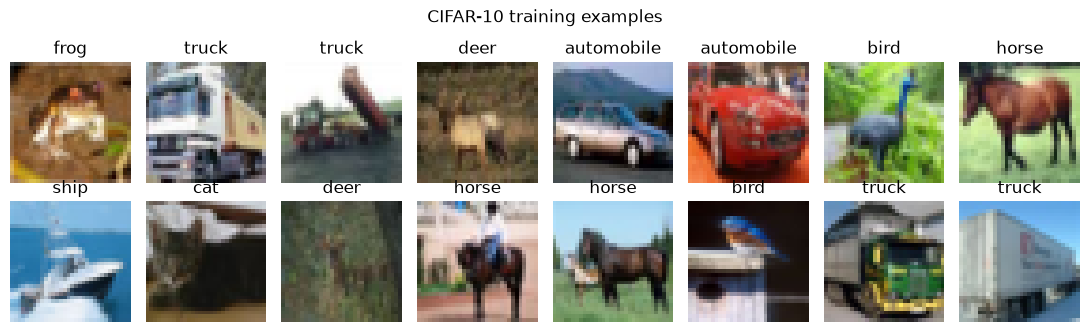

In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
train_dataset = datasets.CIFAR10("data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10("data", train=False, download=True, transform=transform)
class_names = train_dataset.classes

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=0,
)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

def denormalize(image_tensor):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    standard_deviation = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (image_tensor.cpu() * standard_deviation + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(11, 3.4))
for axis, (image, label) in zip(axes.flat, train_dataset):
    axis.imshow(denormalize(image).permute(1, 2, 0))
    axis.set_title(class_names[label])
    axis.axis("off")
fig.suptitle("CIFAR-10 training examples")
plt.tight_layout()
plt.show()

### 2. Train a compact convolutional network

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, images):
        features = self.features(images).flatten(1)
        return self.classifier(features)


model = SmallCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
history = []

for epoch in range(5):
    model.train()
    train_loss = 0.0
    train_correct = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(images)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()

    model.eval()
    test_correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            logits = model(images.to(DEVICE))
            test_correct += (logits.argmax(dim=1).cpu() == labels).sum().item()

    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss / len(train_dataset),
            "train_accuracy": train_correct / len(train_dataset),
            "test_accuracy": test_correct / len(test_dataset),
        }
    )

history_frame = pd.DataFrame(history)
history_frame.style.format({"train_loss": "{:.3f}", "train_accuracy": "{:.2%}", "test_accuracy": "{:.2%}"})

,epoch,train_loss,train_accuracy,test_accuracy
0,1,1.507,43.69%,47.05%
1,2,1.104,60.22%,59.21%
2,3,0.950,66.21%,66.82%
3,4,0.854,69.76%,65.67%
4,5,0.779,72.51%,71.06%


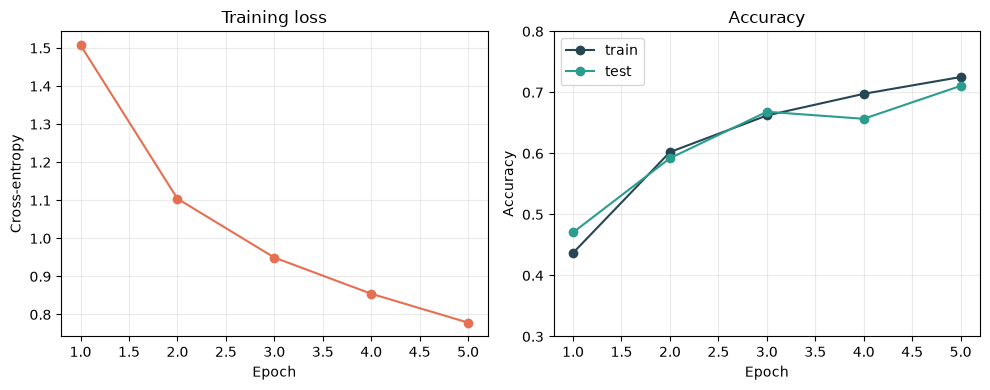

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_frame["epoch"], history_frame["train_loss"], marker="o", color="#e76f51")
axes[0].set(xlabel="Epoch", ylabel="Cross-entropy", title="Training loss")
axes[1].plot(history_frame["epoch"], history_frame["train_accuracy"], marker="o", label="train", color="#264653")
axes[1].plot(history_frame["epoch"], history_frame["test_accuracy"], marker="o", label="test", color="#2a9d8f")
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Accuracy", ylim=(0.3, 0.8))
axes[1].legend()
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3. Inspect class-level errors

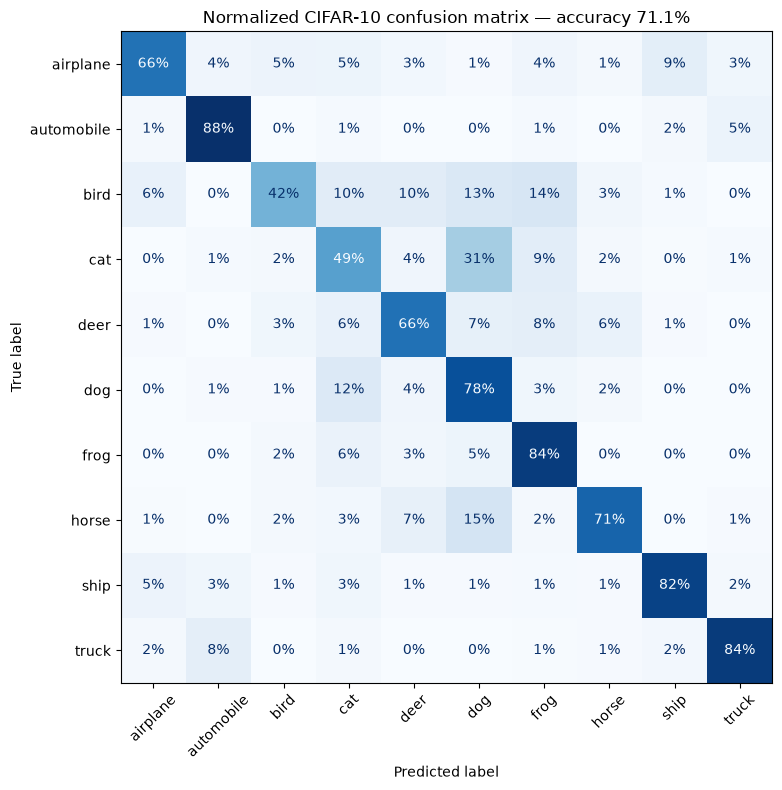

In [5]:
model.eval()
all_predictions = []
all_labels = []
all_images = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        probabilities = torch.softmax(model(images.to(DEVICE)), dim=1).cpu()
        all_probabilities.append(probabilities)
        all_predictions.append(probabilities.argmax(dim=1))
        all_labels.append(labels)
        all_images.append(images)

all_probabilities = torch.cat(all_probabilities)
all_predictions = torch.cat(all_predictions)
all_labels = torch.cat(all_labels)
all_images = torch.cat(all_images)
test_accuracy = (all_predictions == all_labels).float().mean().item()

matrix = confusion_matrix(all_labels.numpy(), all_predictions.numpy(), labels=range(10), normalize="true")
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".0%", xticks_rotation=45
)
ax.set_title(f"Normalized CIFAR-10 confusion matrix — accuracy {test_accuracy:.1%}")
plt.tight_layout()
plt.show()

### 4. Compute saliency for one correct prediction and one mistake

For each image, differentiate the predicted-class score with respect to every
input pixel. Large absolute gradients mark pixels where a small change would most
affect that score. This is local sensitivity—not a causal explanation.

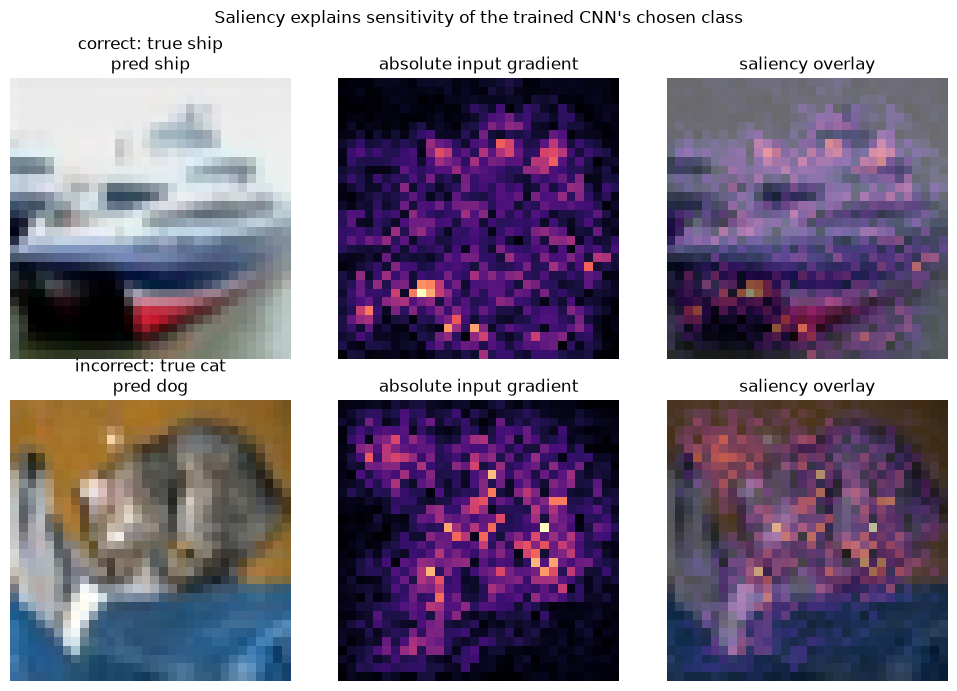

In [6]:
correct_index = torch.where(all_predictions == all_labels)[0][0].item()
incorrect_index = torch.where(all_predictions != all_labels)[0][0].item()


def input_saliency(index):
    image = all_images[index : index + 1].clone().to(DEVICE).requires_grad_(True)
    model.zero_grad(set_to_none=True)
    logits = model(image)
    predicted_class = logits.argmax(dim=1).item()
    logits[0, predicted_class].backward()
    saliency = image.grad.detach().abs().amax(dim=1).squeeze().cpu()
    saliency /= saliency.max().clamp_min(1e-12)
    return predicted_class, saliency


examples = [("correct", correct_index), ("incorrect", incorrect_index)]
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

for row, (status, index) in enumerate(examples):
    predicted_class, saliency = input_saliency(index)
    image = denormalize(all_images[index]).permute(1, 2, 0)
    actual_class = all_labels[index].item()

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"{status}: true {class_names[actual_class]}" + chr(10) + f"pred {class_names[predicted_class]}"
    )
    axes[row, 1].imshow(saliency, cmap="magma")
    axes[row, 1].set_title("absolute input gradient")
    axes[row, 2].imshow(image)
    axes[row, 2].imshow(saliency, cmap="magma", alpha=0.55)
    axes[row, 2].set_title("saliency overlay")
    for axis in axes[row]:
        axis.axis("off")

fig.suptitle("Saliency explains sensitivity of the trained CNN's chosen class")
plt.tight_layout()
plt.show()

## Checks

In [7]:
_, correct_saliency = input_saliency(correct_index)
_, incorrect_saliency = input_saliency(incorrect_index)

assert history_frame["train_loss"].iloc[-1] < history_frame["train_loss"].iloc[0]
assert test_accuracy > 0.60
assert all_probabilities.shape == (10_000, 10)
assert torch.allclose(all_probabilities.sum(dim=1), torch.ones(10_000), atol=1e-5)
assert torch.isfinite(correct_saliency).all() and torch.isfinite(incorrect_saliency).all()
assert correct_saliency.max().item() == 1.0 and incorrect_saliency.max().item() == 1.0

print(f"Checks passed: held-out accuracy={test_accuracy:.1%}; trained-model saliency maps are finite and normalized.")

Checks passed: held-out accuracy=71.1%; trained-model saliency maps are finite and normalized.


## Next Steps

- Compare raw gradients with SmoothGrad, Integrated Gradients, and Grad-CAM.
- Check whether explanations are stable under tiny, label-preserving perturbations.
- Train longer with augmentation and a validation-based stopping rule.
- Validate explanations against known masks or controlled synthetic cues.

A visually plausible heatmap can still be unstable or unfaithful. The critical
improvement over the rough prototype is that these gradients come from a model
with learned weights and measured behavior—not from random parameters.